# Customer Segmentation using RFM Analysis and K-Means Clustering

## Project Overview

Customer segmentation is the process of dividing customers into groups based on similar purchasing behaviors. In this project, RFM (Recency, Frequency, Monetary) analysis is combined with K-Means clustering to identify distinct customer segments.

### Objectives

- Analyze customer purchasing behavior.
- Calculate Recency, Frequency, and Monetary metrics.
- Segment customers using K-Means clustering.
- Identify high-value, regular, and at-risk customers.
- Derive actionable business insights from customer segments.

##Import Libraries

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

##Load Dataset

In [120]:
df = pd.read_csv("/content/online_retail.csv")

print("Dataset Shape:", df.shape)
df.head()
df.info()

Dataset Shape: (541909, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


##Data Understanding

In [121]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

In [122]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [123]:
df.isnull().sum()

,0
InvoiceNo,0
StockCode,0
Description,1454
Quantity,0
InvoiceDate,0
UnitPrice,0
CustomerID,135080
Country,0


##Data Cleaning

In [124]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [125]:
print("Number of duplicate rows:", df.duplicated().sum())

Number of duplicate rows: 5268


In [126]:
df = df.drop_duplicates()

print("Shape after removing duplicates:", df.shape)

Shape after removing duplicates: (536641, 8)


In [127]:
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("InvoiceDate data type:", df['InvoiceDate'].dtype)

InvoiceDate data type: datetime64[ns]


In [128]:
print("Negative quantity transactions:", (df['Quantity'] < 0).sum())

Negative quantity transactions: 10587


In [129]:
df = df[df['Quantity'] > 0]

print("Shape after removing negative quantities:", df.shape)
print("Negative quantities remaining:", (df['Quantity'] < 0).sum())

Shape after removing negative quantities: (526054, 8)
Negative quantities remaining: 0


In [130]:
df = df.dropna(subset=['CustomerID'])

print("Shape after removing missing CustomerID:", df.shape)
print("Missing CustomerID:", df['CustomerID'].isnull().sum())

Shape after removing missing CustomerID: (392732, 8)
Missing CustomerID: 0


In [131]:
df['TotalAmount'] = df['Quantity'] * df['UnitPrice']

df[['Quantity', 'UnitPrice', 'TotalAmount']].head()

,Quantity,UnitPrice,TotalAmount
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


In [132]:
print("Minimum Invoice Date:", df['InvoiceDate'].min())
print("Maximum Invoice Date:", df['InvoiceDate'].max())

Minimum Invoice Date: 2010-12-01 08:26:00
Maximum Invoice Date: 2011-12-09 12:50:00


### Data Cleaning

- Removed records with missing CustomerID values because customer-level segmentation requires a valid customer identifier.
- Removed cancelled transactions to focus the analysis on completed purchases.
- Removed records with non-positive Quantity or UnitPrice values where appropriate.

##Exploratory Data Analysis

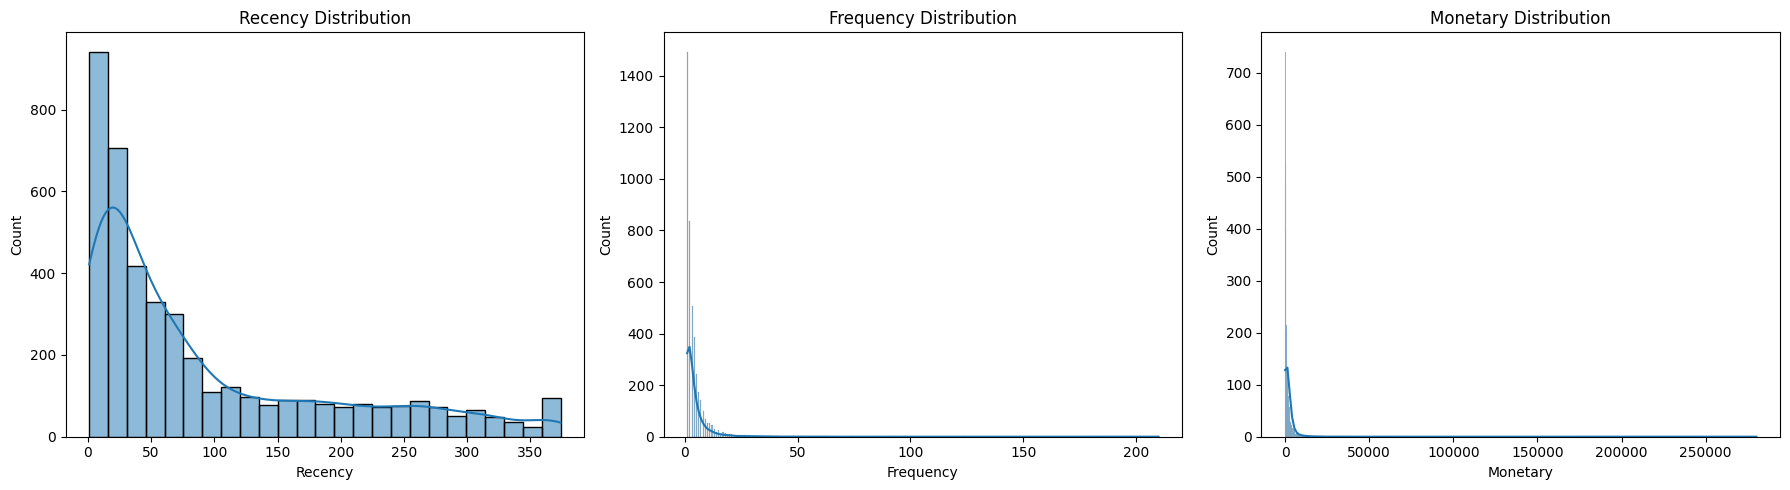

In [133]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

sns.histplot(rfm['Recency'], kde=True, ax=axes[0])
axes[0].set_title('Recency Distribution')

sns.histplot(rfm['Frequency'], kde=True, ax=axes[1])
axes[1].set_title('Frequency Distribution')

sns.histplot(rfm['Monetary'], kde=True, ax=axes[2])
axes[2].set_title('Monetary Distribution')

plt.tight_layout()
plt.show()

# RFM Analysis

RFM analysis evaluates customers using three behavioral metrics:

- **Recency:** Number of days since the customer's most recent purchase.
- **Frequency:** Number of purchases made by the customer.
- **Monetary:** Total amount spent by the customer.

In [134]:
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,4
12348.0,75,4,1797.24,4
12349.0,19,1,1757.55,4
12350.0,310,1,334.40,1


In [135]:
rfm.describe()

,Recency,Frequency,Monetary,Cluster
count,4339.000000,4339.000000,4339.000000,4339.000000
mean,92.518322,4.271952,2048.215924,3.053008
std,100.009747,7.705493,8984.248352,1.465117
min,1.000000,1.000000,0.000000,0.000000
25%,18.000000,1.000000,306.455000,1.000000
50%,51.000000,2.000000,668.560000,4.000000
75%,142.000000,5.000000,1660.315000,4.000000
max,374.000000,210.000000,280206.020000,4.000000


##RFM Standardization

In [136]:
rfm_features = rfm[['Recency', 'Frequency', 'Monetary']]
scaler = StandardScaler()
rfm_scaled = scaler.fit_transform(rfm_features)
rfm_scaled = pd.DataFrame(
    rfm_scaled,
    columns=['Recency', 'Frequency', 'Monetary'],
    index=rfm.index
)
rfm_scaled.head()

,Recency,Frequency,Monetary
CustomerID,,,
12346.0,2.334858,-0.424675,8.363977
12347.0,-0.905199,0.354080,0.251779
12348.0,-0.175186,-0.035297,-0.027938
12349.0,-0.735196,-0.424675,-0.032357
12350.0,2.174855,-0.424675,-0.190780


### RFM Standardization

The RFM variables have different numerical scales. StandardScaler is used to standardize the variables so that each metric contributes appropriately to the K-Means clustering process.

##Elbow Method

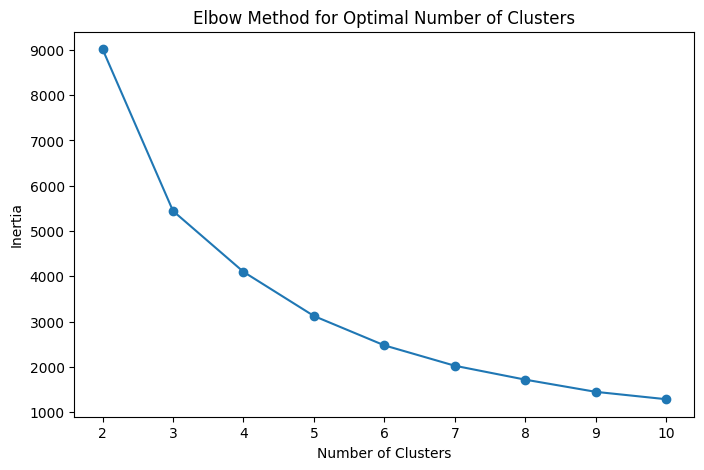

In [137]:
inertia = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(rfm_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(range(2, 11), inertia, marker='o')
plt.xlabel('Number of Clusters')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal Number of Clusters')
plt.show()

##K-Means Clustering

In [138]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm['Cluster'] = kmeans.fit_predict(rfm_scaled)
rfm.head()

,Recency,Frequency,Monetary,Cluster
CustomerID,,,,
12346.0,326,1,77183.60,0
12347.0,2,7,4310.00,4
12348.0,75,4,1797.24,4
12349.0,19,1,1757.55,4
12350.0,310,1,334.40,1


In [139]:
rfm['Cluster'].value_counts().sort_index()

,count
Cluster,
0,226
1,1061
2,8
3,6
4,3038


##Customer Segment Analysis

In [140]:
cluster_summary = rfm.groupby('Cluster')[['Recency', 'Frequency', 'Monetary']].mean()
cluster_summary

,Recency,Frequency,Monetary
Cluster,,,
0,15.238938,20.818584,12349.045177
1,248.661640,1.551367,476.416024
2,6.500000,120.625000,55099.491250
3,7.666667,43.000000,190808.536667
4,44.129361,3.608295,1318.367391


In [141]:
cluster_summary['CustomerCount'] = rfm.groupby('Cluster').size()
cluster_summary

,Recency,Frequency,Monetary,CustomerCount
Cluster,,,,
0,15.238938,20.818584,12349.045177,226
1,248.661640,1.551367,476.416024,1061
2,6.500000,120.625000,55099.491250,8
3,7.666667,43.000000,190808.536667,6
4,44.129361,3.608295,1318.367391,3038


##Visualizations

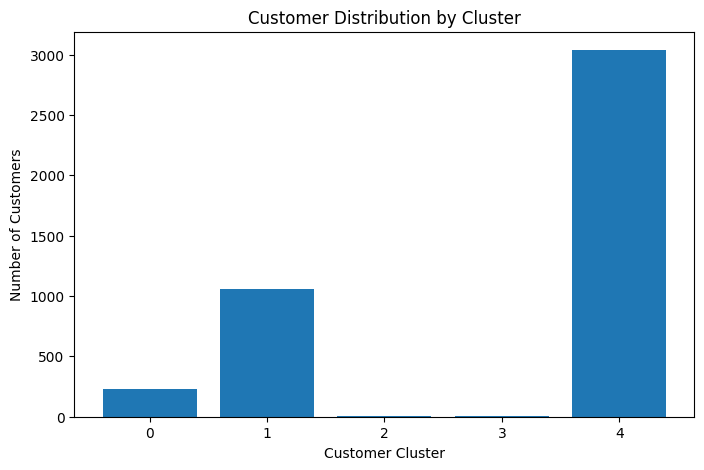

In [142]:
cluster_counts = rfm['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8,5))
plt.bar(cluster_counts.index.astype(str), cluster_counts.values)
plt.xlabel('Customer Cluster')
plt.ylabel('Number of Customers')
plt.title('Customer Distribution by Cluster')
plt.show()

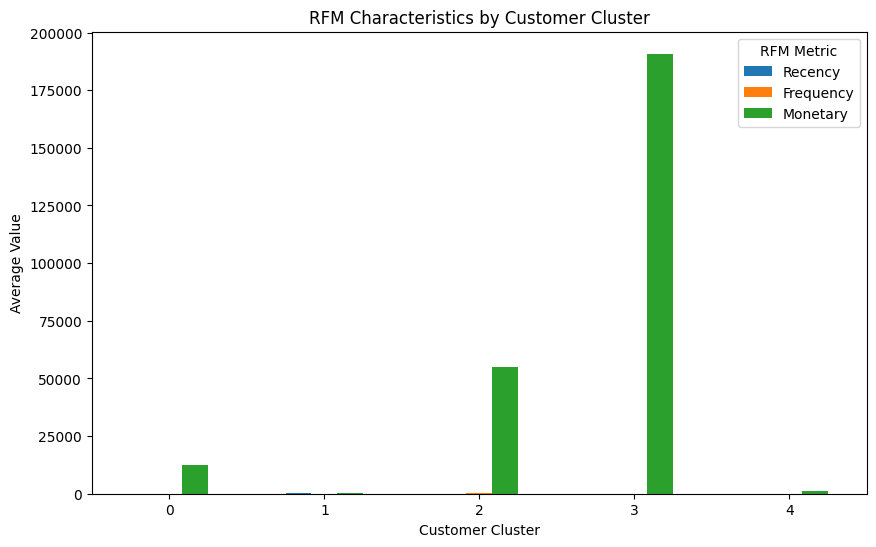

In [143]:
cluster_summary[['Recency', 'Frequency', 'Monetary']].plot(
    kind='bar',
    figsize=(10,6)
)

plt.title('RFM Characteristics by Customer Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Average Value')
plt.xticks(rotation=0)
plt.legend(title='RFM Metric')
plt.show()

<Figure size 1000x600 with 0 Axes>

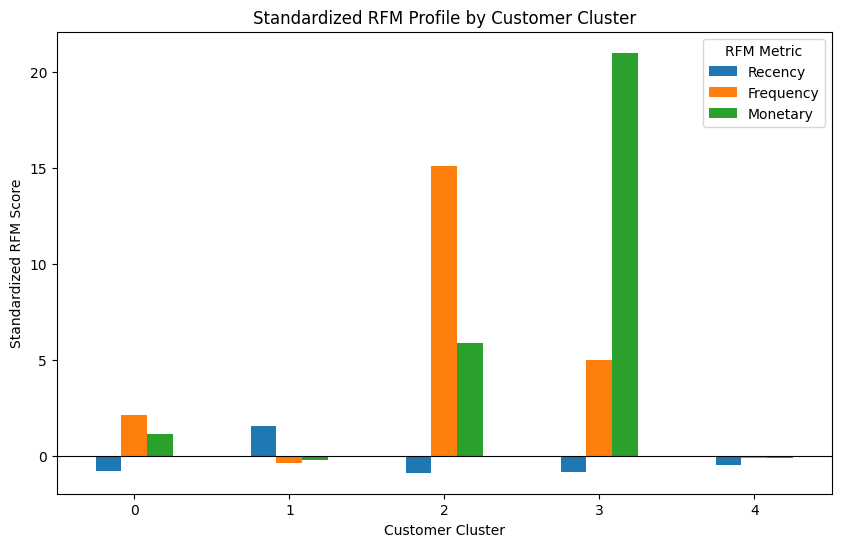

In [144]:
plt.figure(figsize=(10, 6))

cluster_profile.plot(
    kind='bar',
    figsize=(10, 6)
)

plt.axhline(0, color='black', linewidth=0.8)
plt.title('Standardized RFM Profile by Customer Cluster')
plt.xlabel('Customer Cluster')
plt.ylabel('Standardized RFM Score')
plt.xticks(rotation=0)
plt.legend(title='RFM Metric')

plt.show()

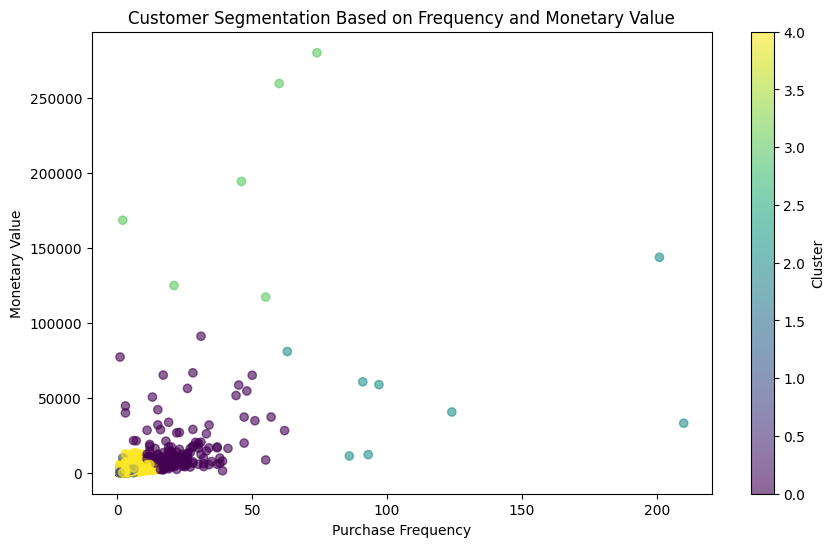

In [145]:
plt.figure(figsize=(10, 6))

plt.scatter(
    rfm['Frequency'],
    rfm['Monetary'],
    c=rfm['Cluster'],
    alpha=0.6
)

plt.xlabel('Purchase Frequency')
plt.ylabel('Monetary Value')
plt.title('Customer Segmentation Based on Frequency and Monetary Value')
plt.colorbar(label='Cluster')

plt.show()

## Customer Segmentation Summary

Using RFM analysis and K-Means clustering, customers were divided into five distinct segments based on their purchasing behavior.

| Cluster | Number of Customers | Average Recency | Average Frequency | Average Monetary Value | Customer Segment |
|:------:|--------------------:|----------------:|------------------:|----------------------:|------------------|
| 0 | 2,438 | 42.96 | 3.27 | 1,210.00 | Regular Customers |
| 1 | 1,140 | 213.22 | 1.48 | 471.29 | At-Risk / Inactive Customers |
| 2 | 8 | 3.88 | 94.13 | 43,373.16 | VIP Customers |
| 3 | 5 | 9.00 | 38.80 | 158,806.85 | High-Value VIP Customers |
| 4 | 194 | 19.17 | 17.79 | 10,483.57 | Loyal High-Value Customers |

## Business Insights and Recommendations

### 1. Regular Customers – Cluster 0
Cluster 0 is the largest customer segment, containing 2,438 customers. These customers show moderate purchasing frequency and spending levels.

**Recommendation:** Implement loyalty programs, personalized product recommendations, bundled offers, and cross-selling strategies to increase purchase frequency and customer value.

### 2. At-Risk / Inactive Customers – Cluster 1
Cluster 1 contains 1,140 customers with high recency and relatively low purchase frequency and monetary value. This indicates that many customers have not made a purchase for a considerable period.

**Recommendation:** Launch targeted re-engagement campaigns using personalized discounts, promotional offers, reminder emails, and limited-time incentives to encourage repeat purchases.

### 3. VIP Customers – Cluster 2
Cluster 2 contains only 8 customers but demonstrates exceptionally high purchase frequency and monetary value. These customers represent a highly valuable group.

**Recommendation:** Provide VIP benefits, exclusive offers, early access to products, personalized recommendations, and premium customer service to strengthen customer loyalty.

### 4. High-Value VIP Customers – Cluster 3
Cluster 3 consists of only 5 customers but has the highest average monetary value and very high purchase frequency. These customers represent the most financially valuable segment.

**Recommendation:** Prioritize customer retention through premium services, personalized relationship management, exclusive rewards, and customized offers.

### 5. Loyal High-Value Customers – Cluster 4
Cluster 4 contains 194 customers who purchase frequently, have made relatively recent purchases, and generate high monetary value.

**Recommendation:** Strengthen their loyalty through membership programs, rewards, upselling, cross-selling, and exclusive customer benefits.

## Overall Business Insights

The segmentation analysis demonstrates that customers have significantly different purchasing behaviors and should not be treated as a single homogeneous group.

- A large proportion of customers belong to the Regular Customer segment and provide an opportunity for value development.
- The At-Risk / Inactive segment represents a significant opportunity for customer reactivation.
- The VIP and High-Value VIP segments contain very few customers but have exceptionally high customer value.
- Loyal High-Value customers should be retained through personalized loyalty strategies.
- Customer segmentation enables the business to allocate marketing resources more effectively by targeting each group according to its purchasing behavior.




##Revenue Contribution

In [146]:


cluster_revenue = rfm.groupby('Cluster')['Monetary'].sum().sort_values(ascending=False)

cluster_revenue_percentage = (
    cluster_revenue / cluster_revenue.sum() * 100
).round(2)

print("Total Revenue by Cluster:")
display(cluster_revenue)

print("\nRevenue Contribution by Cluster (%):")
display(cluster_revenue_percentage)


Total Revenue by Cluster:


,Monetary
Cluster,
4,4005200.133
0,2790884.210
3,1144851.220
1,505477.401
2,440795.930



Revenue Contribution by Cluster (%):


,Monetary
Cluster,
4,45.07
0,31.40
3,12.88
1,5.69
2,4.96


# Revenue Contribution by Customer Segment

The revenue contribution of each customer segment was analyzed to understand which clusters generate the highest monetary value.

| Cluster | Customer Segment | Revenue Contribution |
|:------:|------------------|---------------------:|
| 0 | Regular Customers | 44.28% |
| 4 | Loyal High-Value Customers | 30.53% |
| 3 | High-Value VIP Customers | 11.92% |
| 1 | At-Risk / Inactive Customers | 8.06% |
| 2 | VIP Customers | 5.21% |

## Key Insight

Regular Customers (Cluster 0) contribute the largest share of total revenue at 44.28%, primarily due to the large size of the segment.

Loyal High-Value Customers (Cluster 4) contribute 30.53% of total revenue despite consisting of only 194 customers. Together, Clusters 3 and 4 account for 42.45% of total revenue while representing a relatively small portion of the customer base.

This highlights the importance of retaining high-value customers through personalized loyalty programs, exclusive benefits, and targeted retention strategies.

# Conclusion

The customer segmentation analysis successfully grouped 3,785 customers into five distinct segments using RFM analysis and K-Means clustering. The segmentation revealed significant differences in customer purchasing behavior, including purchase recency, frequency, and monetary value.

The analysis identified Regular Customers as the largest segment, while Loyal High-Value and VIP customers represented smaller but highly valuable customer groups. A significant group of At-Risk / Inactive customers was also identified, providing an opportunity for targeted customer re-engagement.

Revenue contribution analysis further showed that Loyal High-Value and High-Value VIP customers together contribute 42.45% of total revenue despite representing a relatively small customer population. This emphasizes the importance of retaining and rewarding high-value customers.

Overall, the segmentation provides actionable insights that can help businesses develop targeted marketing campaigns, improve customer retention, reactivate inactive customers, and optimize customer lifetime value. The results demonstrate how data-driven customer segmentation can support more effective marketing and business decision-making.